<a href="https://colab.research.google.com/github/blckvia/DeepLearningSchool/blob/main/simpsons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle

In [5]:
import os

os.environ['KAGGLE_API_TOKEN'] = "yourkey"

In [6]:
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [7]:
!kaggle competitions download -c journey-to-springfield1

100% 521M/521M [00:30<00:00, 18.0MB/s]



In [8]:
import zipfile

zip_path = "journey-to-springfield1.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import pandas as pd
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
from pathlib import Path
import os
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import os
from pathlib import Path
from torch.utils.data import Subset, DataLoader, Dataset
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import multiprocessing as mp

In [ ]:
# try:
#     mp.set_start_method('fork', force=True)
# except RuntimeError:
#     pass

In [23]:
dataset_path = Path("/content/data/train/simpsons_dataset")
dataset_test_path  = Path("/content/data/testset/testset")

for class_dir in dataset_path.iterdir():
    if not class_dir.is_dir():
        continue
    for f in class_dir.glob("aug_*.jpg"):
        f.unlink()

class_counts = {}
for class_dir in dataset_path.iterdir():
    if class_dir.is_dir():
        count = len(list(class_dir.glob("*.jpg")))
        class_counts[class_dir.name] = count

class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

for cls, count in class_counts.items():
    print(f"{cls:40s} {count}")

print(f"\nВсего классов: {len(class_counts)}")
print(f"Всего изображений: {sum(class_counts.values())}")

homer_simpson                            2246
ned_flanders                             1454
moe_szyslak                              1452
lisa_simpson                             1354
bart_simpson                             1342
marge_simpson                            1291
krusty_the_clown                         1206
principal_skinner                        1194
charles_montgomery_burns                 1193
milhouse_van_houten                      1079
chief_wiggum                             986
abraham_grampa_simpson                   913
sideshow_bob                             877
apu_nahasapeemapetilon                   623
kent_brockman                            498
comic_book_guy                           469
edna_krabappel                           457
nelson_muntz                             358
lenny_leonard                            310
mayor_quimby                             246
waylon_smithers                          181
maggie_simpson                           128


/tmp/ipykernel_4196/1441819178.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_counts.keys(), rotation=90, fontsize=8)


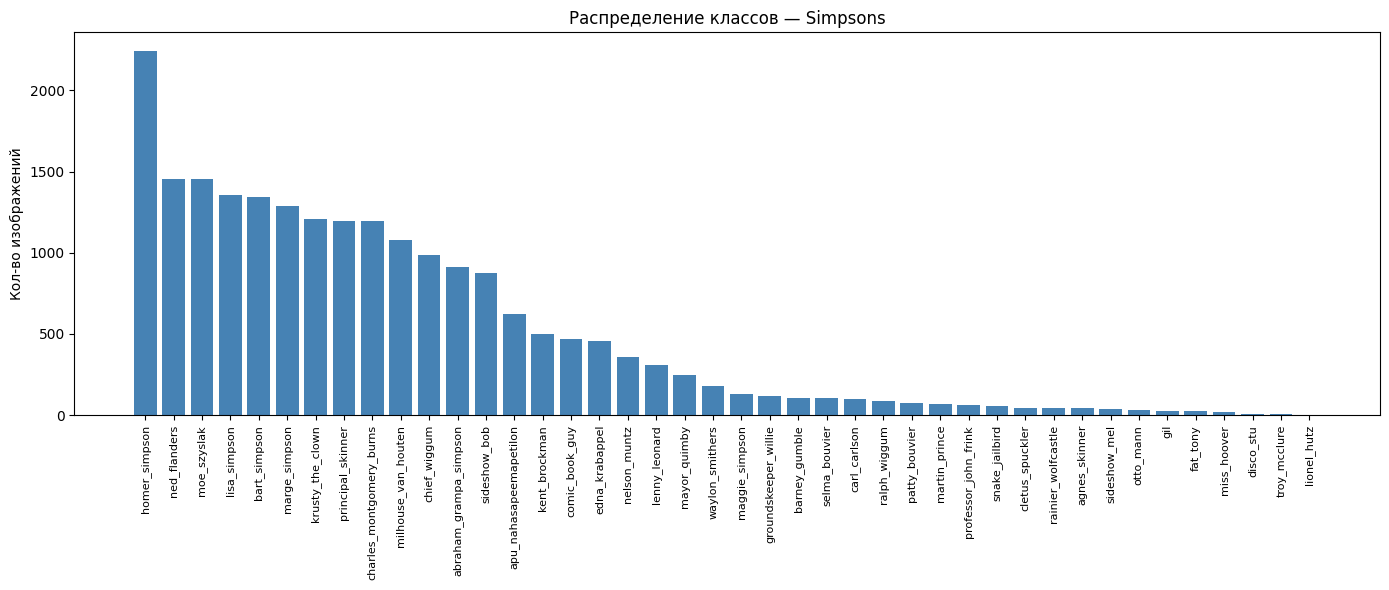

In [24]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(class_counts.keys(), class_counts.values(), color="steelblue")
ax.set_xticklabels(class_counts.keys(), rotation=90, fontsize=8)
ax.set_ylabel("Кол-во изображений")
ax.set_title("Распределение классов — Simpsons")
plt.tight_layout()
plt.show()

In [13]:
from PIL import Image

img_path = "/content/data/train/simpsons_dataset/homer_simpson/pic_0001.jpg"

img = Image.open(img_path)

print(img.size)

(576, 416)


In [25]:
target_count = 300
treshold = 30

augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.5, scale_limit=0.1, rotate_limit=14, p=0.5),
    A.HueSaturationValue(p=0.3),
    A.GaussNoise(p=0.2),
    A.CoarseDropout(p=0.2),
    A.ImageCompression(quality_lower=70, p=0.2),
])

ds_path = Path("/content/data/train/simpsons_dataset/")

for class_dir in ds_path.iterdir():
    if not class_dir.is_dir():
        continue

    images = list(class_dir.glob("*jpg"))
    count = len(images)

    if count >= target_count or count <= treshold:
        continue

    need = target_count - count
    print(f"{class_dir.name}: {count}, генерируем {need} изображений" )

    generated = 0
    while generated < need:
        for img_path in images:
            if generated >= need:
                break
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            augmented = augment(image=img)["image"]
            save_path = class_dir / f"aug_{generated}_{img_path.name}"
            cv2.imwrite(str(save_path), cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))
            generated += 1

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_4196/2228013184.py:11: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=70, p=0.2),


martin_prince: 71, генерируем 229 изображений
agnes_skinner: 42, генерируем 258 изображений
otto_mann: 32, генерируем 268 изображений
barney_gumble: 106, генерируем 194 изображений
ralph_wiggum: 89, генерируем 211 изображений
selma_bouvier: 103, генерируем 197 изображений
snake_jailbird: 55, генерируем 245 изображений
professor_john_frink: 65, генерируем 235 изображений
maggie_simpson: 128, генерируем 172 изображений
mayor_quimby: 246, генерируем 54 изображений
patty_bouvier: 72, генерируем 228 изображений
groundskeeper_willie: 121, генерируем 179 изображений
cletus_spuckler: 47, генерируем 253 изображений
waylon_smithers: 181, генерируем 119 изображений
carl_carlson: 98, генерируем 202 изображений
sideshow_mel: 40, генерируем 260 изображений
rainier_wolfcastle: 45, генерируем 255 изображений


/tmp/ipykernel_4196/1065499563.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_counts.keys(), rotation=90, fontsize=8)


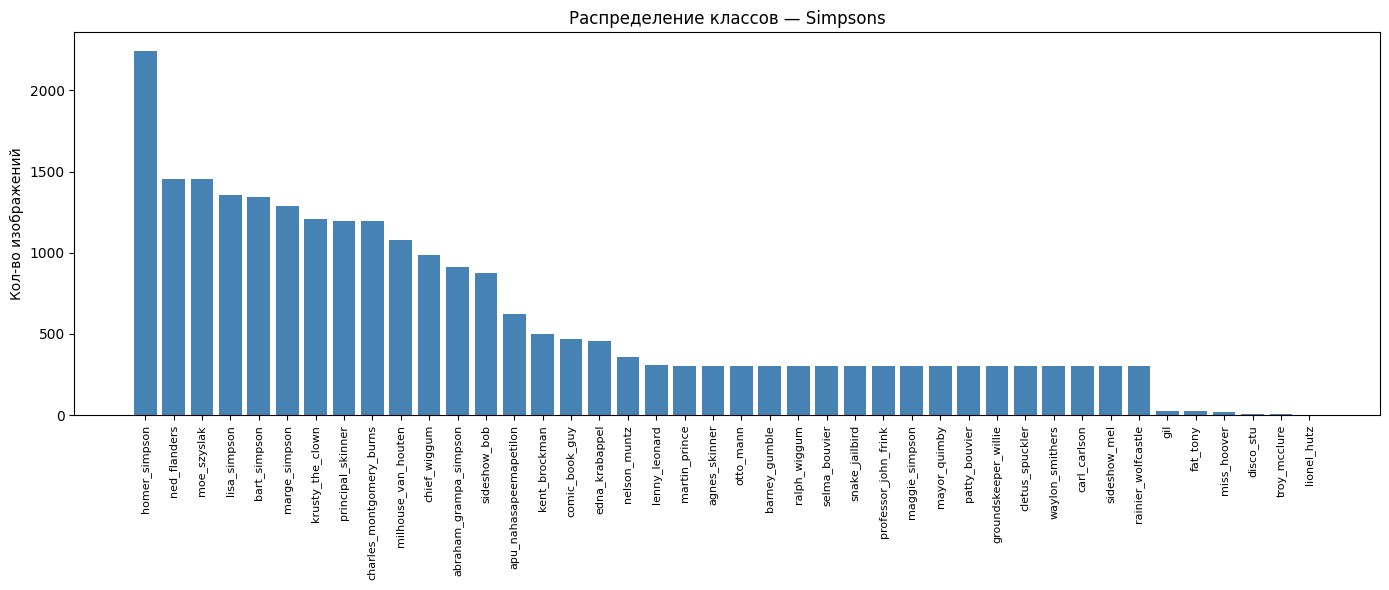

In [27]:
class_counts = {}

for class_name in os.listdir(ds_path):
    class_path = os.path.join(ds_path, class_name)

    if os.path.isdir(class_path):
        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        class_counts[class_name] = len(images)

class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(class_counts.keys(), class_counts.values(), color="steelblue")
ax.set_xticklabels(class_counts.keys(), rotation=90, fontsize=8)
ax.set_ylabel("Кол-во изображений")
ax.set_title("Распределение классов — Simpsons")
plt.tight_layout()
plt.show()

In [28]:
class_counts = {}
for class_dir in dataset_path.iterdir():
    if class_dir.is_dir():
        count = len(list(class_dir.glob("*.jpg")))
        class_counts[class_dir.name] = count

class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

for cls, count in class_counts.items():
    print(f"{cls:40s} {count}")

print(f"\nВсего классов: {len(class_counts)}")
print(f"Всего изображений: {sum(class_counts.values())}")

homer_simpson                            2246
ned_flanders                             1454
moe_szyslak                              1452
lisa_simpson                             1354
bart_simpson                             1342
marge_simpson                            1291
krusty_the_clown                         1206
principal_skinner                        1194
charles_montgomery_burns                 1193
milhouse_van_houten                      1079
chief_wiggum                             986
abraham_grampa_simpson                   913
sideshow_bob                             877
apu_nahasapeemapetilon                   623
kent_brockman                            498
comic_book_guy                           469
edna_krabappel                           457
nelson_muntz                             358
lenny_leonard                            310
martin_prince                            300
agnes_skinner                            300
otto_mann                                300


In [35]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

In [31]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [36]:
pin = torch.cuda.is_available()

full_pic = datasets.ImageFolder(dataset_path)
class_names = full_pic.classes
N = len(full_pic)
targets = np.array(full_pic.targets)

train_idx, val_idx = train_test_split(
    np.arange(N),
    test_size=0.15,
    stratify=targets,
    random_state=42,
)
train_subset = Subset(full_pic, train_idx)
val_subset = Subset(full_pic, val_idx)

class TransformedSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        img, label = self.subset[index]
        return self.transform(img), label

image_datasets = {
    'train': TransformedSubset(train_subset, data_transforms['train']),
    'val':   TransformedSubset(val_subset,   data_transforms['val']),
}

loaders = {
    'train': DataLoader(image_datasets['train'], batch_size=64, shuffle=True,
                        num_workers=4, pin_memory=pin),
    'valid': DataLoader(image_datasets['val'],   batch_size=128, shuffle=False,
                        num_workers=4, pin_memory=pin),
}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}



In [ ]:
print(f"Dataset sizes: {dataset_sizes}")

Dataset sizes: {'train': 22271, 'val': 3931}


In [ ]:
image_datasets["train"][0]

(tensor([[[-1.1589, -1.1589, -1.1589,  ...,  1.1015,  1.1015,  1.1015],
          [-1.1589, -1.1589, -1.1589,  ...,  1.1015,  1.1015,  1.1015],
          [-1.1589, -1.1589, -1.1589,  ...,  1.1015,  1.1015,  1.1015],
          ...,
          [ 0.4679,  0.5193,  0.5022,  ..., -0.3883, -0.3883, -0.3883],
          [ 0.5022,  0.5022,  0.5022,  ..., -0.3712, -0.3712, -0.3712],
          [ 0.5022,  0.5022,  0.5022,  ..., -0.3712, -0.3712, -0.3712]],
 
         [[ 0.1176,  0.1176,  0.1176,  ...,  1.2556,  1.2556,  1.2556],
          [ 0.1176,  0.1176,  0.1176,  ...,  1.2556,  1.2556,  1.2556],
          [ 0.1176,  0.1176,  0.1176,  ...,  1.2556,  1.2556,  1.2556],
          ...,
          [-0.1275, -0.0924, -0.1099,  ...,  0.7479,  0.7479,  0.7479],
          [-0.1625, -0.1625, -0.1625,  ...,  0.7479,  0.7479,  0.7479],
          [-0.1625, -0.1625, -0.1625,  ...,  0.7479,  0.7479,  0.7479]],
 
         [[ 1.0888,  1.0888,  1.0888,  ...,  1.4722,  1.4722,  1.4722],
          [ 1.0888,  1.0888,

In [40]:
NUM_CLASSES = len(class_names)

weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
model = models.convnext_tiny(weights=weights)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 245MB/s] 


In [ ]:
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [ ]:
for p in model.features.parameters():
    p.requires_grad = False

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)

In [32]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()

    running_loss, seen = 0.0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for X_batch, y_batch in tqdm(loader, leave=False):
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)


            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            running_loss += loss.item() * X_batch.size(0)
            seen += X_batch.size(0)

            preds = logits.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average="macro")

    return running_loss / seen, f1


In [ ]:
epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=5e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_val_acc = 0

for epoch in range(epochs):
    train_loss, train_f1 = run_epoch(model, loaders["train"], criterion, optimizer, device, train=True)
    val_loss, val_f1 = run_epoch(model, loaders["valid"], criterion, optimizer, device, train=False)
    scheduler.step()

    print(f"Epoch {epoch+1}: "
          f"train_loss={train_loss:.4f} f1={train_f1:.4f} | "
          f"val_loss={val_loss:.4f} f1={val_f1:.4f}")

    if val_f1 > best_val_acc:
        best_val_acc = val_f1
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  ↑ saved (best f1={val_f1:.4f})")



  0%|          | 0/348 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

Epoch 1: train_loss=2.2795 f1=0.3433 | val_loss=1.4181 f1=0.5677
  ↑ saved (best f1=0.5677)


  0%|          | 0/348 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x10eedaca0>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x10eedaca0>Traceback (most recent call last):

  File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
      File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
self._shutdown_workers()
      File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
self._shutdown_workers()    
if w.is_alive():  File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

     if w.is_alive(): 
          ^ ^ ^^^^^^^^^^^^^^^^^^^^^
  File "/Users/blckvia/.pyenv/versions/3.12.12/lib/python3.12/multiprocessing/proc

...

  0%|          | 0/31 [00:00<?, ?it/s]

Epoch 9: train_loss=1.1210 f1=0.6849 | val_loss=0.7753 f1=0.7871
  ↑ saved (best f1=0.7871)


  0%|          | 0/348 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

Epoch 10: train_loss=1.1155 f1=0.6849 | val_loss=0.7728 f1=0.7862


In [ ]:
model.load_state_dict(torch.load("best_model.pt", map_location=device))

for p in model.features.parameters():
    p.requires_grad = False

for p in model.features[5:].parameters():
    p.requires_grad = True

num_epochs = 10
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(
    (
        {"params": model.features[5:].parameters(), "lr": 1e-4},
        {"params": model.classifier.parameters(),   "lr": 3e-4},
    ),
    weight_decay=5e-2,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

for epoch in range(num_epochs):
    train_loss, train_f1 = run_epoch(model, loaders["train"], criterion, optimizer, device, train=True)
    val_loss, val_f1 = run_epoch(model, loaders["valid"], criterion, optimizer, device, train=False)
    scheduler.step()

    print(f"Epoch {epoch+1}: "
          f"train_loss={train_loss:.4f} f1={train_f1:.4f} | "
          f"val_loss={val_loss:.4f} f1={val_f1:.4f}")

    if val_f1 > best_val_acc:
        best_val_acc = val_f1
        torch.save(model.state_dict(), "best_model_second.pt")
        print(f"  ↑ saved (best f1={val_f1:.4f})")



  0%|          | 0/348 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x10eedaca0>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x10eedaca0>  File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__

Traceback (most recent call last):
      File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
self._shutdown_workers()    self._shutdown_workers()  File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

      File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
if w.is_alive():    
if w.is_alive():Exception ignored in:  
<function _MultiProcessingDataLoaderIter.__del__ at 0x10eedaca0>  
 Traceback (most recent call l

Epoch 1: train_loss=1.4091 f1=0.7714 | val_loss=0.9361 f1=0.9324
  ↑ saved (best f1=0.9324)


  0%|          | 0/348 [00:00<?, ?it/s]

...

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x10eedaca0><function _MultiProcessingDataLoaderIter.__del__ at 0x10eedaca0>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/Users/blckvia/Desktop/SImpsons/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        if w.is_alive():if w.is_alive():

              ^^^^^^^^^^^^^^^^^^^^^^^^

  File "/Users/blckvia/.pyenv/versions/3.12.12/lib/python3.12/multiprocessing/pr

Epoch 9: train_loss=0.9140 f1=0.9370 | val_loss=0.7770 f1=0.9723


  0%|          | 0/348 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

Epoch 10: train_loss=0.9124 f1=0.9390 | val_loss=0.7760 f1=0.9734
  ↑ saved (best f1=0.9734)


In [50]:
from PIL import Image


class TestDataset(Dataset):
    def __init__(self, root, transform):
        self.files = sorted(
            Path(root).glob("*.jpg"),
            key=lambda p: int(p.stem.replace("img", "")),
        )
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        img = Image.open(self.files[i]).convert("RGB")
        return self.transform(img), self.files[i].name


test_ds = TestDataset(dataset_test_path, data_transforms["val"])
test_loader = DataLoader(
    test_ds, batch_size=128, shuffle=False,
    num_workers=4, pin_memory=pin,
)
print(f"Test images: {len(test_ds)}")

model.load_state_dict(torch.load("best_model_second.pt", map_location=device))
model.eval()

ids, predict = [], []
with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc="Inference"):
        X_batch = X_batch.to(device, non_blocking=True)
        logits = model(X_batch)
        preds = logits.argmax(1).cpu().numpy()
        ids.extend(y_batch)
        predict.extend(class_names[p] for p in preds)

submission = pd.DataFrame({"Id": ids, "Expected": predict})
submission.to_csv("submission.csv", index=False)

print("Done")


In [37]:
import timm

V2_SIZE = 384
data_transforms_v2 = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(V2_SIZE, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    'val': transforms.Compose([
        transforms.Resize(int(V2_SIZE * 256 / 224)),
        transforms.CenterCrop(V2_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

image_datasets_v2 = {
    'train': TransformedSubset(train_subset, data_transforms_v2['train']),
    'val':   TransformedSubset(val_subset,   data_transforms_v2['val']),
}

loaders_v2 = {
    'train': DataLoader(image_datasets_v2['train'], batch_size=24, shuffle=True,
                        num_workers=4, pin_memory=pin),
    'valid': DataLoader(image_datasets_v2['val'],   batch_size=32, shuffle=False,
                        num_workers=4, pin_memory=pin),
}
print(f"Train: {len(image_datasets_v2['train'])} | Val: {len(image_datasets_v2['val'])}")


Train: 20818 | Val: 3674


In [41]:
model_v2 = timm.create_model(
    "convnextv2_base.fcmae_ft_in22k_in1k_384",
    pretrained=True,
    num_classes=NUM_CLASSES,
)

for p in model_v2.parameters():
    p.requires_grad = False
for p in model_v2.head.parameters():
    p.requires_grad = True

model_v2 = model_v2.to(device)

trainable = sum(p.numel() for p in model_v2.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_v2.parameters())
print(f"Trainable: {trainable:,} / {total:,}")
print("Stages:", [n for n, _ in model_v2.stages.named_children()])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/355M [00:00<?, ?B/s]

Trainable: 45,098 / 87,735,850
Stages: ['0', '1', '2', '3']


In [44]:
epochs_v2_p1 = 10
criterion_v2 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_v2 = optim.AdamW(
    filter(lambda p: p.requires_grad, model_v2.parameters()),
    lr=1e-3, weight_decay=5e-2,
)
scheduler_v2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_v2, T_max=epochs_v2_p1)

best_val_v2 = 0.0

for epoch in range(epochs_v2_p1):
    train_loss, train_f1 = run_epoch(model_v2, loaders_v2["train"], criterion_v2, optimizer_v2, device, train=True)
    val_loss,   val_f1   = run_epoch(model_v2, loaders_v2["valid"], criterion_v2, optimizer_v2, device, train=False)
    scheduler_v2.step()

    print(f"[V2 P1] Epoch {epoch+1}: "
          f"train_loss={train_loss:.4f} f1={train_f1:.4f} | "
          f"val_loss={val_loss:.4f} f1={val_f1:.4f}")

    if val_f1 > best_val_v2:
        best_val_v2 = val_f1
        torch.save(model_v2.state_dict(), "best_model_v2.pt")
        print(f"  ↑ saved (best f1={val_f1:.4f})")


  0%|          | 0/868 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

[V2 P1] Epoch 1: train_loss=1.6541 f1=0.5940 | val_loss=1.4000 f1=0.6800
  ↑ saved (best f1=0.6800)


  0%|          | 0/868 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

...

  0%|          | 0/115 [00:00<?, ?it/s]

[V2 P1] Epoch 9: train_loss=0.9801 f1=0.9678 | val_loss=1.1915 f1=0.8168


  0%|          | 0/868 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

[V2 P1] Epoch 10: train_loss=0.9751 f1=0.9683 | val_loss=1.1896 f1=0.8162


In [47]:
model_v2.load_state_dict(torch.load("/content/best_model_v2.pt", map_location=device))

for p in model_v2.parameters():
    p.requires_grad = False
for p in model_v2.stages[2].parameters():
    p.requires_grad = True
for p in model_v2.stages[3].parameters():
    p.requires_grad = True
for p in model_v2.norm_pre.parameters():
    p.requires_grad = True
for p in model_v2.head.parameters():
    p.requires_grad = True

epochs_v2_p2 = 6
criterion_v2 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_v2 = optim.AdamW(
    [
        {"params": model_v2.stages[2].parameters(), "lr": 5e-5},
        {"params": model_v2.stages[3].parameters(), "lr": 1e-4},
        {"params": model_v2.norm_pre.parameters(),  "lr": 1e-4},
        {"params": model_v2.head.parameters(),      "lr": 3e-4},
    ],
    weight_decay=5e-2,
)
scheduler_v2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_v2, T_max=epochs_v2_p2)

for epoch in range(epochs_v2_p2):
    train_loss, train_f1 = run_epoch(model_v2, loaders_v2["train"], criterion_v2, optimizer_v2, device, train=True)
    val_loss,   val_f1   = run_epoch(model_v2, loaders_v2["valid"], criterion_v2, optimizer_v2, device, train=False)
    scheduler_v2.step()

    print(f"[V2 P2] Epoch {epoch+1}: "
          f"train_loss={train_loss:.4f} f1={train_f1:.4f} | "
          f"val_loss={val_loss:.4f} f1={val_f1:.4f}")

    if val_f1 > best_val_v2:
        best_val_v2 = val_f1
        torch.save(model_v2.state_dict(), "best_model_v2.pt")
        print(f"  ↑ saved (best f1={val_f1:.4f})")

print(f"\nBest V2 val f1: {best_val_v2:.4f}")


  0%|          | 0/868 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

[V2 P2] Epoch 1: train_loss=0.8296 f1=0.9437 | val_loss=0.7888 f1=0.9395
  ↑ saved (best f1=0.9395)


  0%|          | 0/868 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

...

  0%|          | 0/115 [00:00<?, ?it/s]

[V2 P2] Epoch 5: train_loss=0.6905 f1=0.9944 | val_loss=0.7332 f1=0.9749
  ↑ saved (best f1=0.9749)


  0%|          | 0/868 [00:00<?, ?it/s]

  0%|          | 0/115 [00:00<?, ?it/s]

[V2 P2] Epoch 6: train_loss=0.6881 f1=0.9993 | val_loss=0.7291 f1=0.9517

Best V2 val f1: 0.9749


In [51]:
test_ds_v2 = TestDataset(dataset_test_path, data_transforms_v2["val"])
test_loader_v2 = DataLoader(
    test_ds_v2, batch_size=32, shuffle=False,
    num_workers=4, pin_memory=pin,
)
print(f"Test images: {len(test_ds_v2)}")

model_v2.load_state_dict(torch.load("best_model_v2.pt", map_location=device))
model_v2.eval()

ids_v2, predict_v2 = [], []
with torch.no_grad():
    for X_batch, names in tqdm(test_loader_v2, desc="V2 TTA inference"):
        X_batch = X_batch.to(device, non_blocking=True)
        logits = model_v2(X_batch).softmax(1)
        logits_flip = model_v2(torch.flip(X_batch, dims=[3])).softmax(1)
        probs = (logits + logits_flip) / 2
        preds = probs.argmax(1).cpu().numpy()
        ids_v2.extend(names)
        predict_v2.extend(class_names[p] for p in preds)

submission_v2 = pd.DataFrame({"Id": ids_v2, "Expected": predict_v2})
submission_v2.to_csv("submission_v2.csv", index=False)
print(submission_v2.head())
print(f"\nSaved submission_v2.csv with {len(submission_v2)} rows")


Test images: 991


V2 TTA inference:   0%|          | 0/31 [00:00<?, ?it/s]

         Id      Expected
0  img0.jpg  nelson_muntz
1  img1.jpg  bart_simpson
2  img2.jpg  mayor_quimby
3  img3.jpg  nelson_muntz
4  img4.jpg  lisa_simpson

Saved submission_v2.csv with 991 rows
